In [4]:
import os
import csv
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision.io import read_image
from torchvision import models
from torchvision.transforms import v2 as transforms
from torch.utils.data import Dataset, SubsetRandomSampler
from safetensors.torch import save_model, load_model
import torchvision.transforms.functional as F

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [6]:
class SquarePad:
    def __call__(self, image):
        c, h, w = image.size()
        max_wh = np.max([w, h])
        hp = (max_wh - w) // 2 + max_wh // 10
        vp = (max_wh - h) // 2 + max_wh // 10
        padding = (hp, vp, hp, vp)
        return F.pad(image, padding, 1, 'constant')

def image_transform(test=False):
    # normalize = transforms.Normalize(
    #     mean=[0.4914, 0.4822, 0.4465],
    #     std=[0.2023, 0.1994, 0.2010],
    # )
    mid_transforms = [
    ] if test else [
        # transforms.RandomHorizontalFlip(),
        # transforms.RandomVerticalFlip(),
        #transforms.RandomAffine(degrees=10, translate=(0.1,0.1), scale=(0.9,1.1)),
        #transforms.ColorJitter(),
        # transforms.GaussianBlur(5),
    ]
    return transforms.Compose([
        transforms.ConvertImageDtype(torch.float),
        transforms.RGB(),
        SquarePad(),
    ] + mid_transforms + [
        transforms.Resize((224,224)),
        # normalize,
        transforms.Lambda(lambda x: torch.clamp(x, 0, 1))
    ])


def load_image(path):
    transform = image_transform(test=True)
    image = read_image(path)
    image = transform(image)
    return image

In [7]:
def load_paths(root_dir) -> list:
    filenames = next(os.walk(root_dir), (None, None, []))[2]
    return [os.path.join(root_dir, filename) for filename in filenames]

In [8]:
images_path = '../data/logos'

In [6]:
max_width = 0
max_height = 0
min_width = 1000
min_height = 1000
for path in load_paths(images_path)[:5]:
    image = read_image(path)
    assert image.size()[0] == 3
    width, height = image.size()[1], image.size()[2]
    max_width = max(max_width, width)
    max_height = max(max_height, height)
    min_width = min(min_width, width)
    min_height = min(min_height, height)
print(f'Min size: {min_width}x{min_height}')
print(f'Max size: {max_width}x{max_height}')

Min size: 337x912
Max size: 945x945


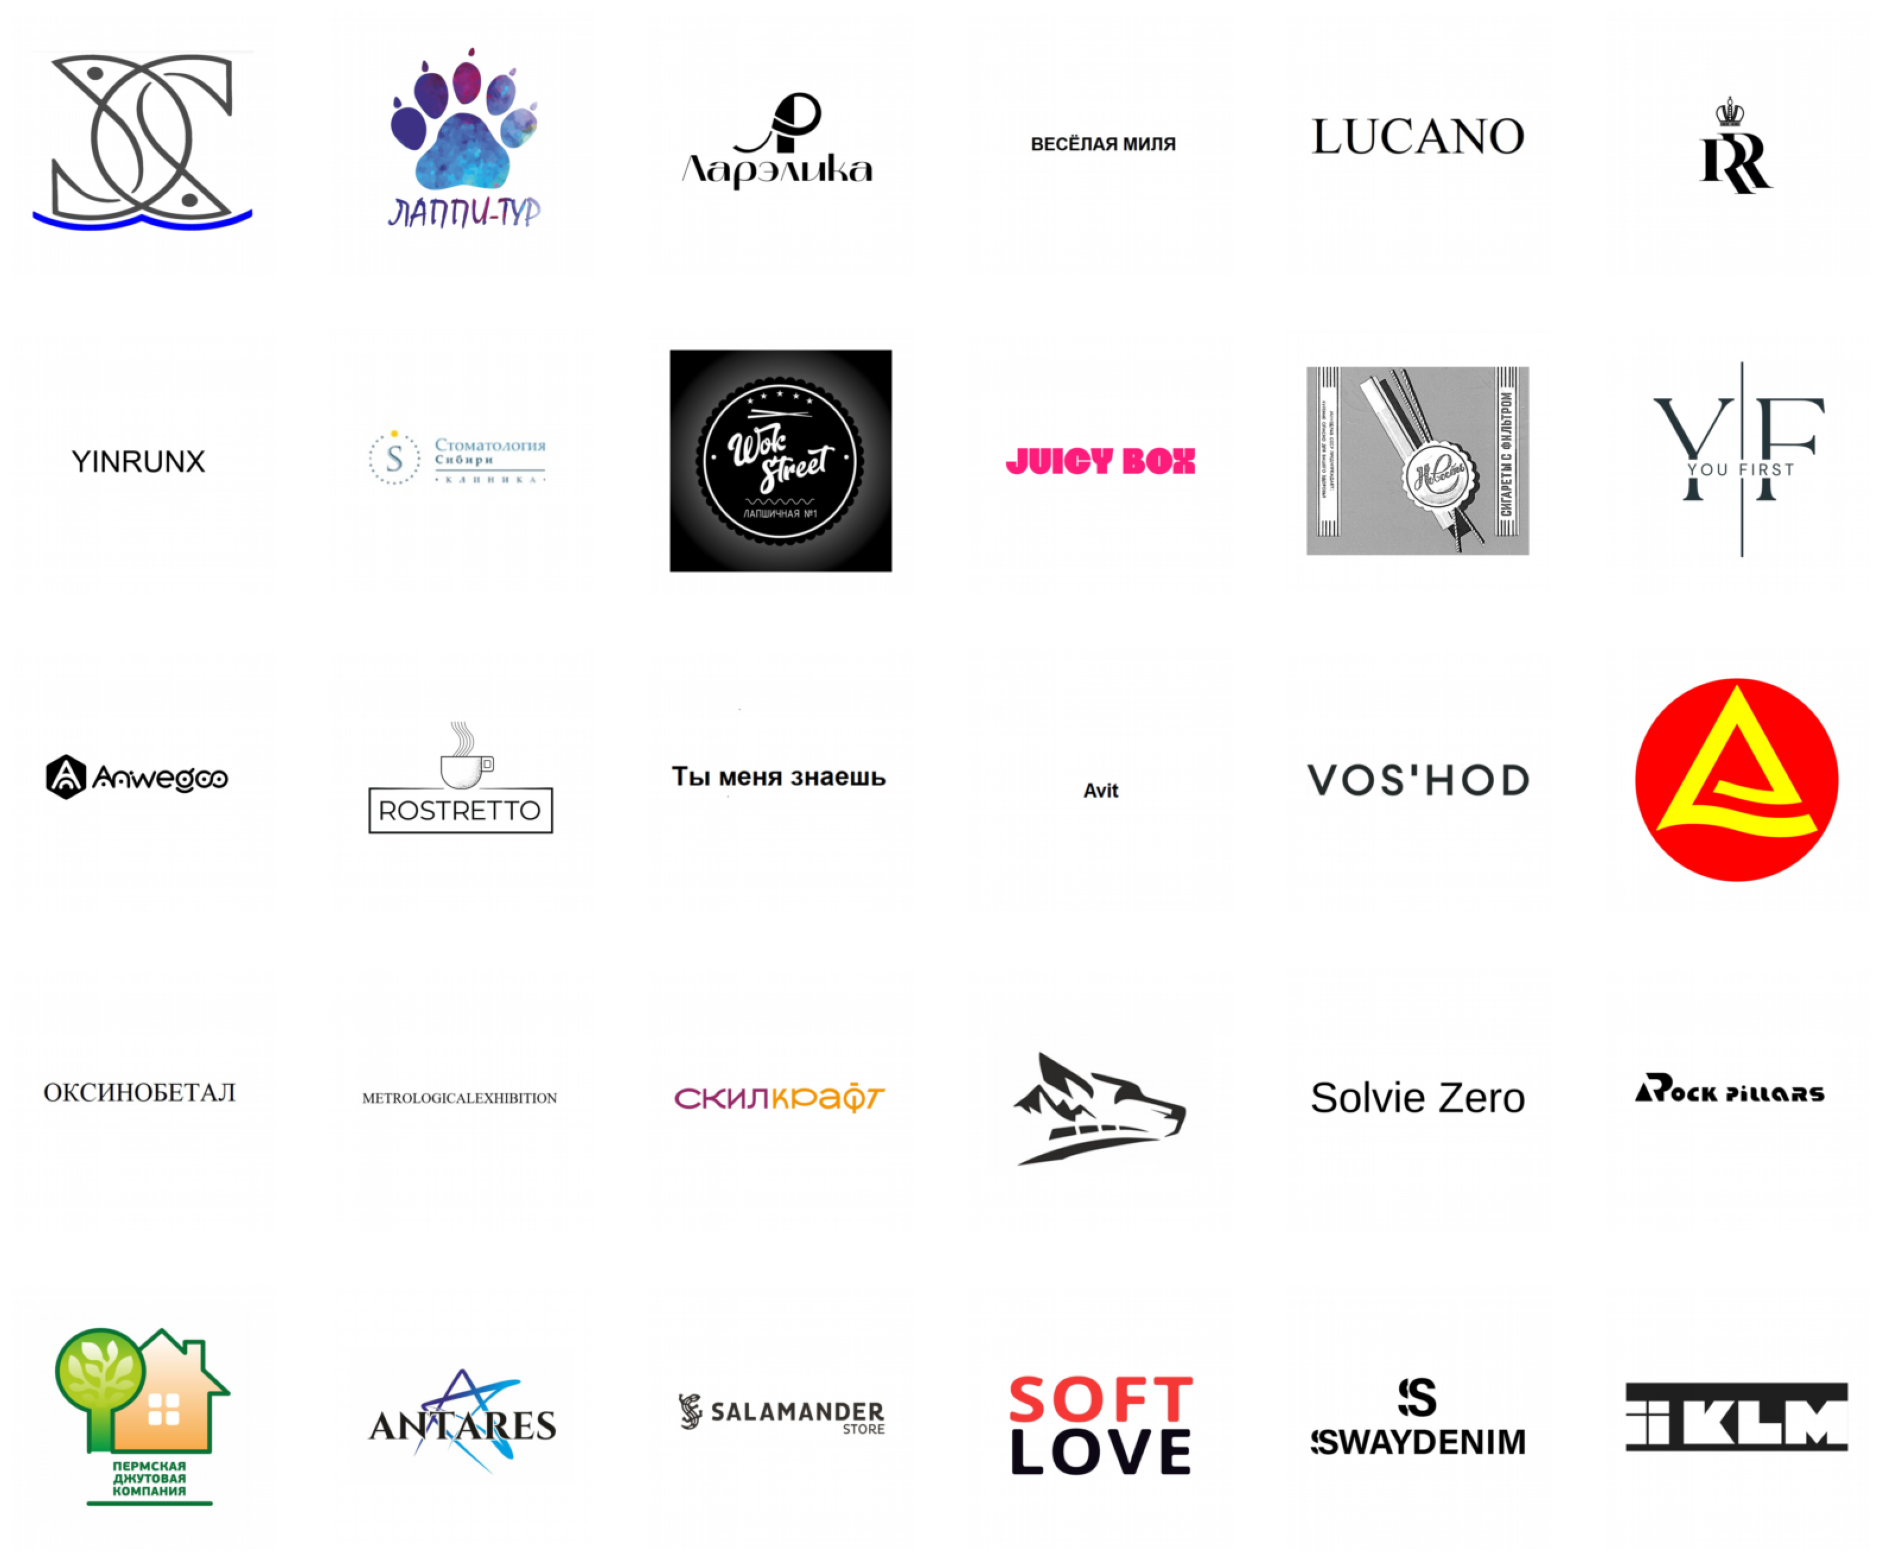

In [7]:
w, h = 6, 5
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

images = load_paths(images_path)

image_paths = []
np.random.shuffle(images)
image_paths.extend(images)

for i, (img_path, ax) in enumerate(zip(image_paths, axs.flatten())):
    img = load_image(img_path)
    #prediction = model(img.unsqueeze(0).to(device)).item()

    ax.imshow(img.transpose(0,1).transpose(1,2))
    ax.set_axis_off()
    #ax.set_title(f'Labelled: {label:.0f}, Predicted: {prediction:.0f}')

plt.show()

In [9]:
class LogosDataset(Dataset):
    def __init__(self, root_dir, frames_limit=None, transform=None):
        self.root = root_dir
        self.transform = transform

        self.images = []

        images = load_paths(root_dir)
        image_paths = []

        if frames_limit is None:
            image_paths = images
        else:
            np.random.shuffle(images)
            image_paths.extend(images[:frames_limit])

        self.images.extend(image_paths)

        print(f'loaded {len(self.images)} paths')

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = read_image(img_path)
        if self.transform:
            image = self.transform(image)
        return image, img_path

In [10]:
def data_loader(data_dir, batch_size, frames_limit=None, shuffle=True, test=False):
    transform = image_transform(test)
    dataset = LogosDataset(data_dir, frames_limit, transform)

    indices = list(range(len(dataset)))
    if shuffle:
        np.random.shuffle(indices)

    sampler = SubsetRandomSampler(indices)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=sampler)
    return loader

In [11]:
loader_test = data_loader('../data/logos', 16, frames_limit=1000, test=True)

loaded 1000 paths


In [12]:
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT).to(device)
#model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT).to(device)
model.eval()
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [13]:
def generate_embeddings(model):
    model = model.to(device)
    embeddings = torch.tensor([]).to(device)
    all_paths = []
    for images, paths in tqdm(loader_test):
        encoding = model(images.to(device)).detach()
        embeddings = torch.cat((embeddings, encoding))
        all_paths += paths
    return embeddings, all_paths

In [14]:
image_embeddings, image_embedding_paths = generate_embeddings(model)
image_embeddings

100%|██████████| 63/63 [00:05<00:00, 12.35it/s]


tensor([[-1.8527, -1.7255, -3.0742,  ..., -0.5477,  0.5600,  2.5180],
        [-2.2693, -1.2629, -3.3128,  ..., -3.3206,  0.1245,  2.7425],
        [-0.3798, -0.1578, -1.0403,  ..., -1.4230,  0.4995,  0.4362],
        ...,
        [-2.1223, -0.9486, -2.1049,  ..., -0.0312, -0.0642,  2.1169],
        [-1.3579, -0.0409, -2.5653,  ..., -1.7917, -0.0645,  0.4167],
        [-1.1133, -0.3623, -2.3015,  ..., -1.7895, -0.3759,  0.3452]],
       device='cuda:0')

In [15]:
def compute_similarity(image_path, embeddings):
    image = load_image(image_path)
    encoded = model.to(device)(image.unsqueeze(0).to(device)).detach()

    similarity_fn = nn.CosineSimilarity()
    def similarity(other_enc):
        return similarity_fn(encoded, other_enc)
    similarity_vec = torch.vmap(similarity)
    return similarity_vec(embeddings)

In [16]:
compute_similarity(image_embedding_paths[0], image_embeddings)

tensor([[1.0000],
        [0.7787],
        [0.7795],
        [0.7604],
        [0.7972],
        [0.7647],
        [0.7168],
        [0.7585],
        [0.7012],
        [0.8315],
        [0.7354],
        [0.6794],
        [0.7357],
        [0.8233],
        [0.7545],
        [0.8287],
        [0.7867],
        [0.8541],
        [0.6966],
        [0.7417],
        [0.6585],
        [0.7600],
        [0.7539],
        [0.7277],
        [0.7573],
        [0.8330],
        [0.7344],
        [0.6268],
        [0.7472],
        [0.7209],
        [0.7453],
        [0.7819],
        [0.7165],
        [0.8351],
        [0.7636],
        [0.8249],
        [0.7652],
        [0.9203],
        [0.7816],
        [0.7868],
        [0.7250],
        [0.7463],
        [0.7656],
        [0.6528],
        [0.8026],
        [0.6638],
        [0.7572],
        [0.8345],
        [0.7604],
        [0.6463],
        [0.7533],
        [0.7275],
        [0.5765],
        [0.6529],
        [0.7416],
        [0

10it [00:00, 23.30it/s]


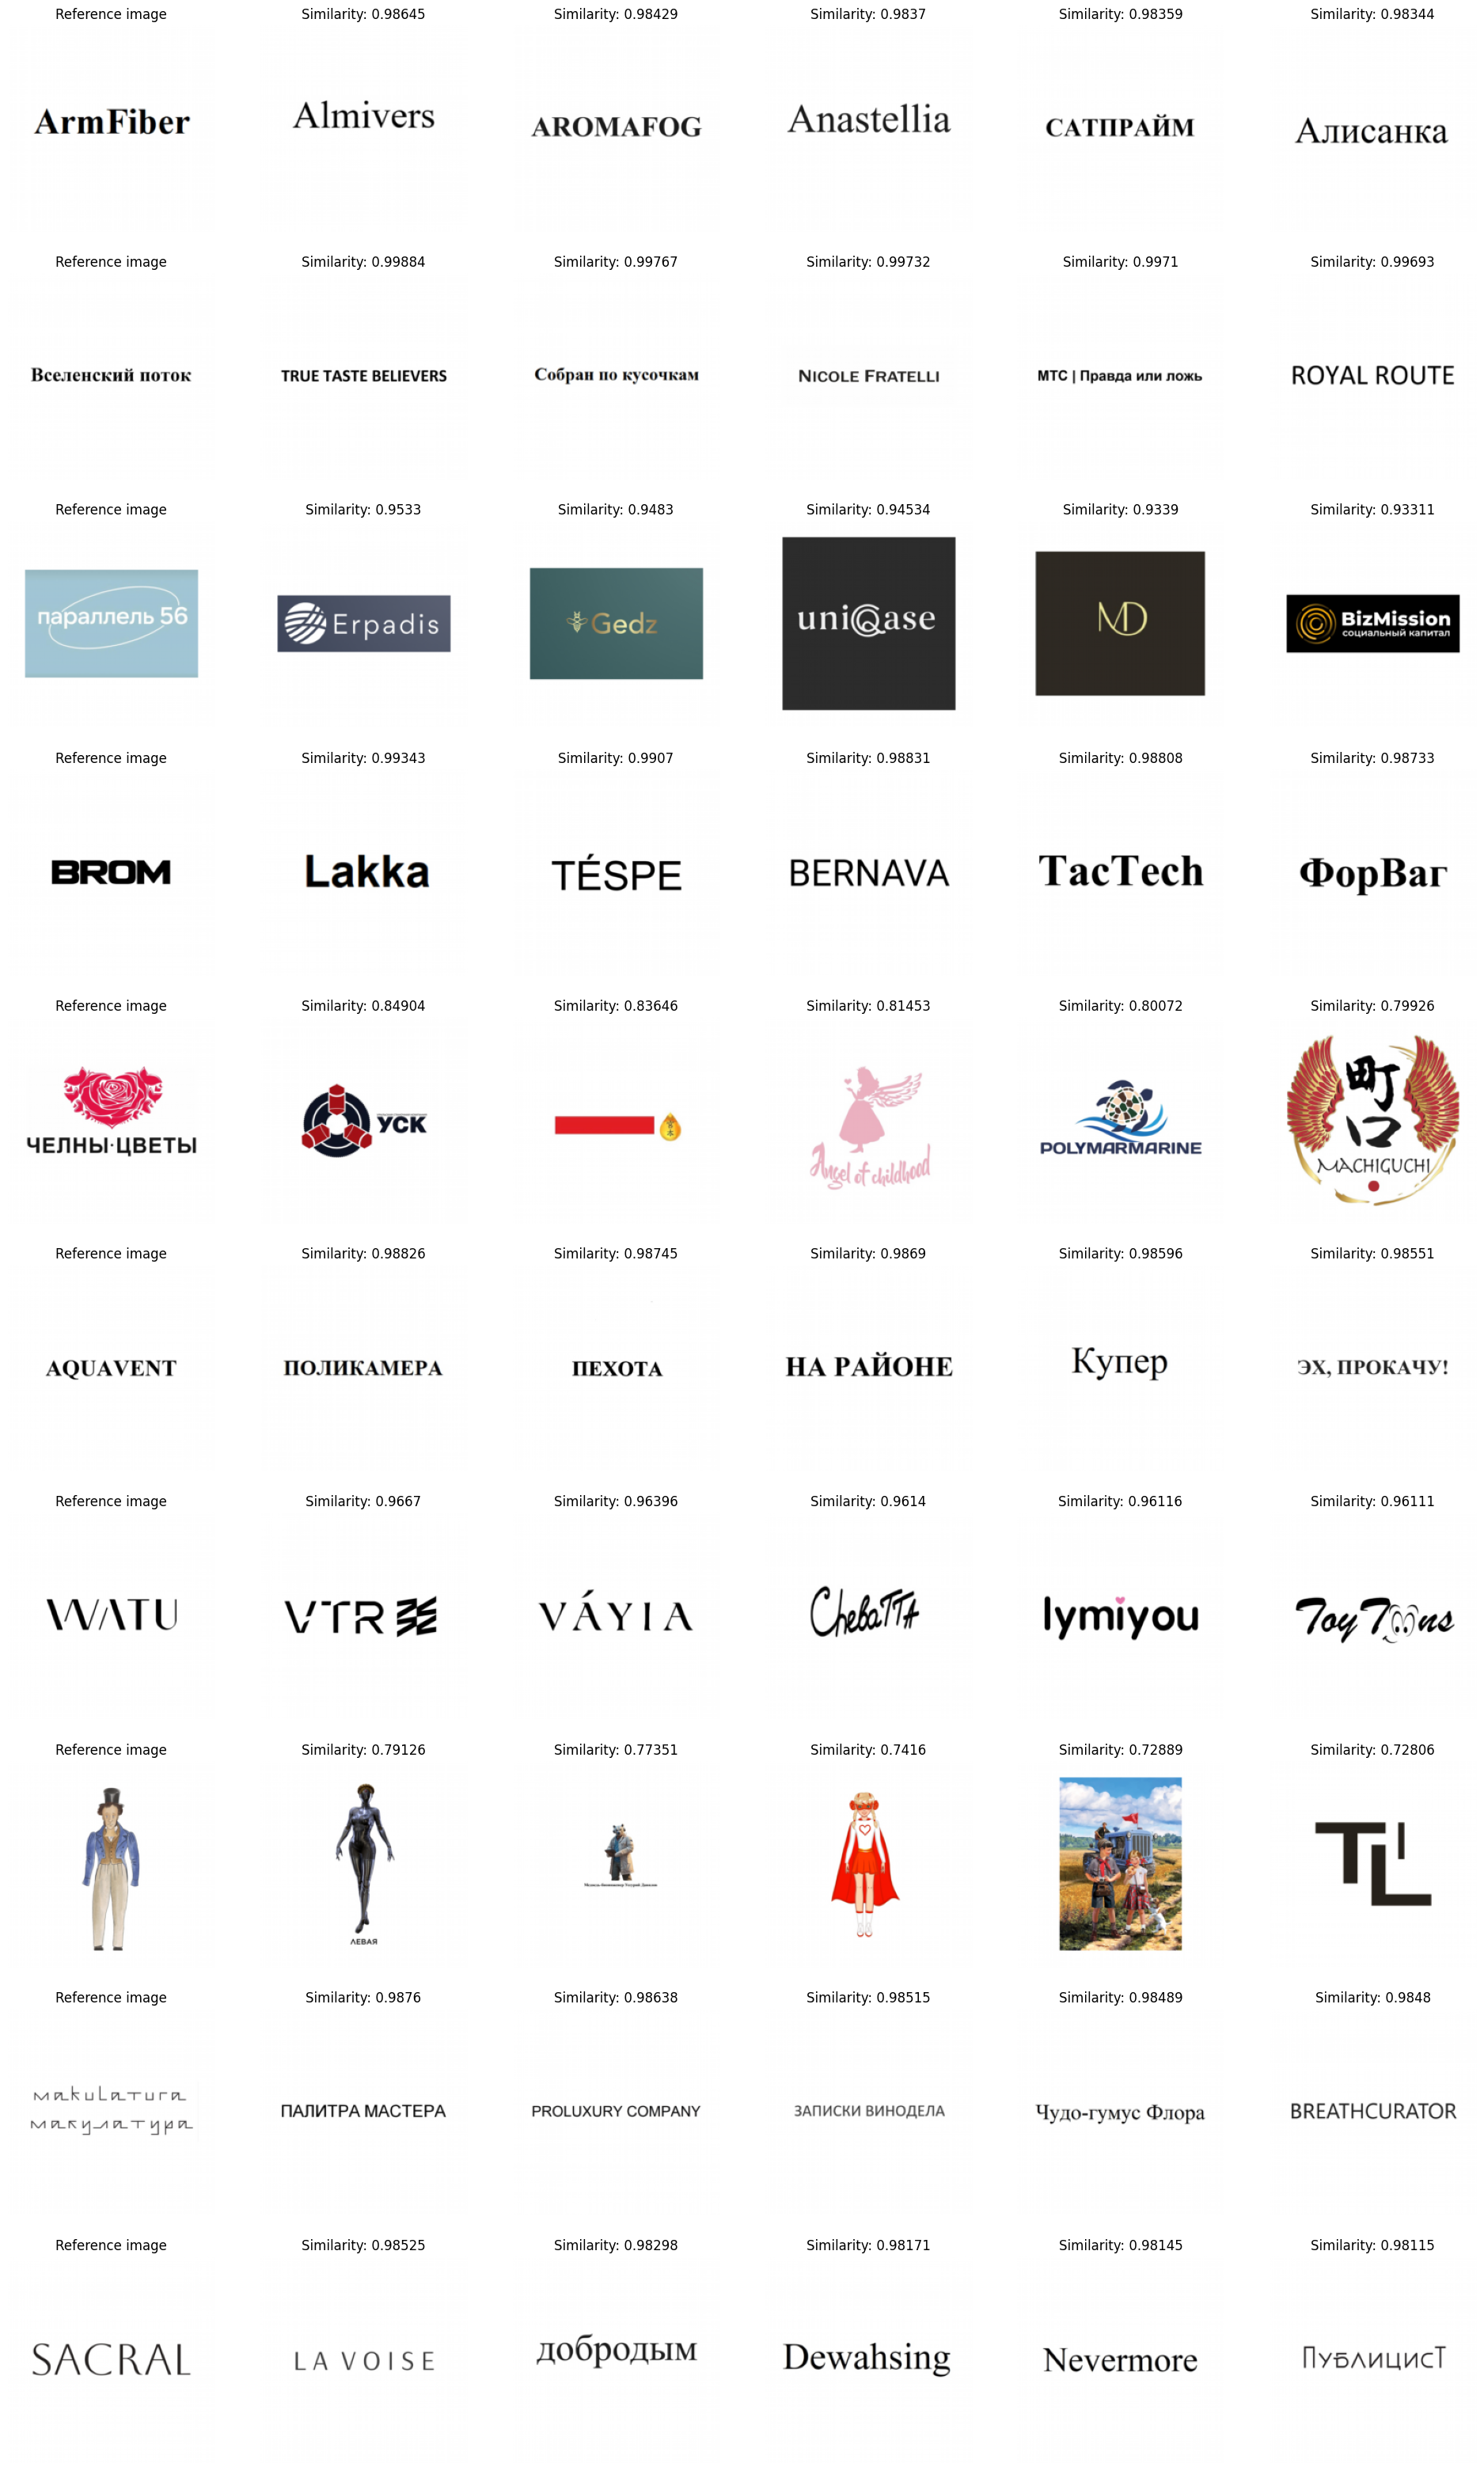

In [16]:
w, h = 6, 10
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

images = load_paths(images_path)

image_paths = []
np.random.shuffle(images)
image_paths.extend(images)

similarity_fn = nn.CosineSimilarity()
model.eval()
for i, ax_row in tqdm(enumerate(axs)):
    img_path = image_paths[i]
    
    similarities = compute_similarity(img_path, image_embeddings).cpu().numpy().flatten()
    top_images = np.argsort(similarities)[::-1]

    for i, ax in enumerate(ax_row):
        if i == 0:
            img = load_image(img_path)
            ax.set_title('Reference image')
        else:
            idx = top_images[i - 1]
            img = load_image(image_embedding_paths[idx])
            similarity = similarities[idx]
            ax.set_title(f'Similarity: {similarity:.5}')
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))

plt.show()

In [17]:
detection_model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
detection_model.classifier.append(nn.Linear(1000, 2)) # 2 classes: text, logo
detection_model.classifier.append(nn.Sigmoid())
load_model(detection_model, '../models/text_detect.safetensors')
detection_model = detection_model.to(device)
detection_model.eval()
detection_model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [18]:
classification, classification_path = generate_embeddings(detection_model)
classification

100%|██████████| 63/63 [00:04<00:00, 13.85it/s]


tensor([[9.8998e-01, 2.0727e-02],
        [9.8663e-01, 3.5663e-02],
        [2.3367e-09, 1.0000e+00],
        ...,
        [4.6154e-05, 9.9985e-01],
        [9.7798e-01, 8.0626e-02],
        [5.2823e-04, 9.9940e-01]], device='cuda:0')

In [19]:
logo_indices = []
for i in range(len(classification_path)):
    cl = classification[i]
    if cl[1] > 0.5: # 50% confidence of logo
        logo_indices.append(i)
logo_indices

[2,
 4,
 5,
 6,
 7,
 8,
 9,
 14,
 16,
 17,
 18,
 21,
 22,
 23,
 25,
 30,
 32,
 33,
 35,
 36,
 39,
 46,
 47,
 49,
 50,
 52,
 55,
 56,
 58,
 59,
 60,
 61,
 68,
 70,
 71,
 72,
 73,
 76,
 77,
 78,
 79,
 81,
 83,
 84,
 86,
 87,
 90,
 91,
 94,
 97,
 99,
 100,
 103,
 105,
 106,
 107,
 108,
 111,
 113,
 114,
 117,
 119,
 121,
 122,
 124,
 125,
 128,
 129,
 130,
 133,
 135,
 136,
 137,
 138,
 139,
 140,
 142,
 144,
 145,
 153,
 156,
 163,
 164,
 166,
 168,
 170,
 171,
 172,
 174,
 175,
 176,
 179,
 180,
 186,
 187,
 189,
 193,
 195,
 197,
 198,
 199,
 204,
 205,
 206,
 208,
 209,
 213,
 216,
 218,
 221,
 222,
 223,
 225,
 227,
 229,
 231,
 232,
 234,
 236,
 237,
 239,
 240,
 243,
 245,
 246,
 247,
 249,
 251,
 252,
 253,
 254,
 255,
 256,
 259,
 260,
 262,
 264,
 268,
 270,
 271,
 274,
 275,
 279,
 283,
 284,
 285,
 295,
 296,
 297,
 298,
 299,
 300,
 301,
 303,
 306,
 307,
 310,
 315,
 318,
 319,
 322,
 323,
 325,
 326,
 328,
 333,
 335,
 337,
 338,
 339,
 346,
 350,
 351,
 354,
 355,
 359,
 3

10it [00:00, 20.57it/s]


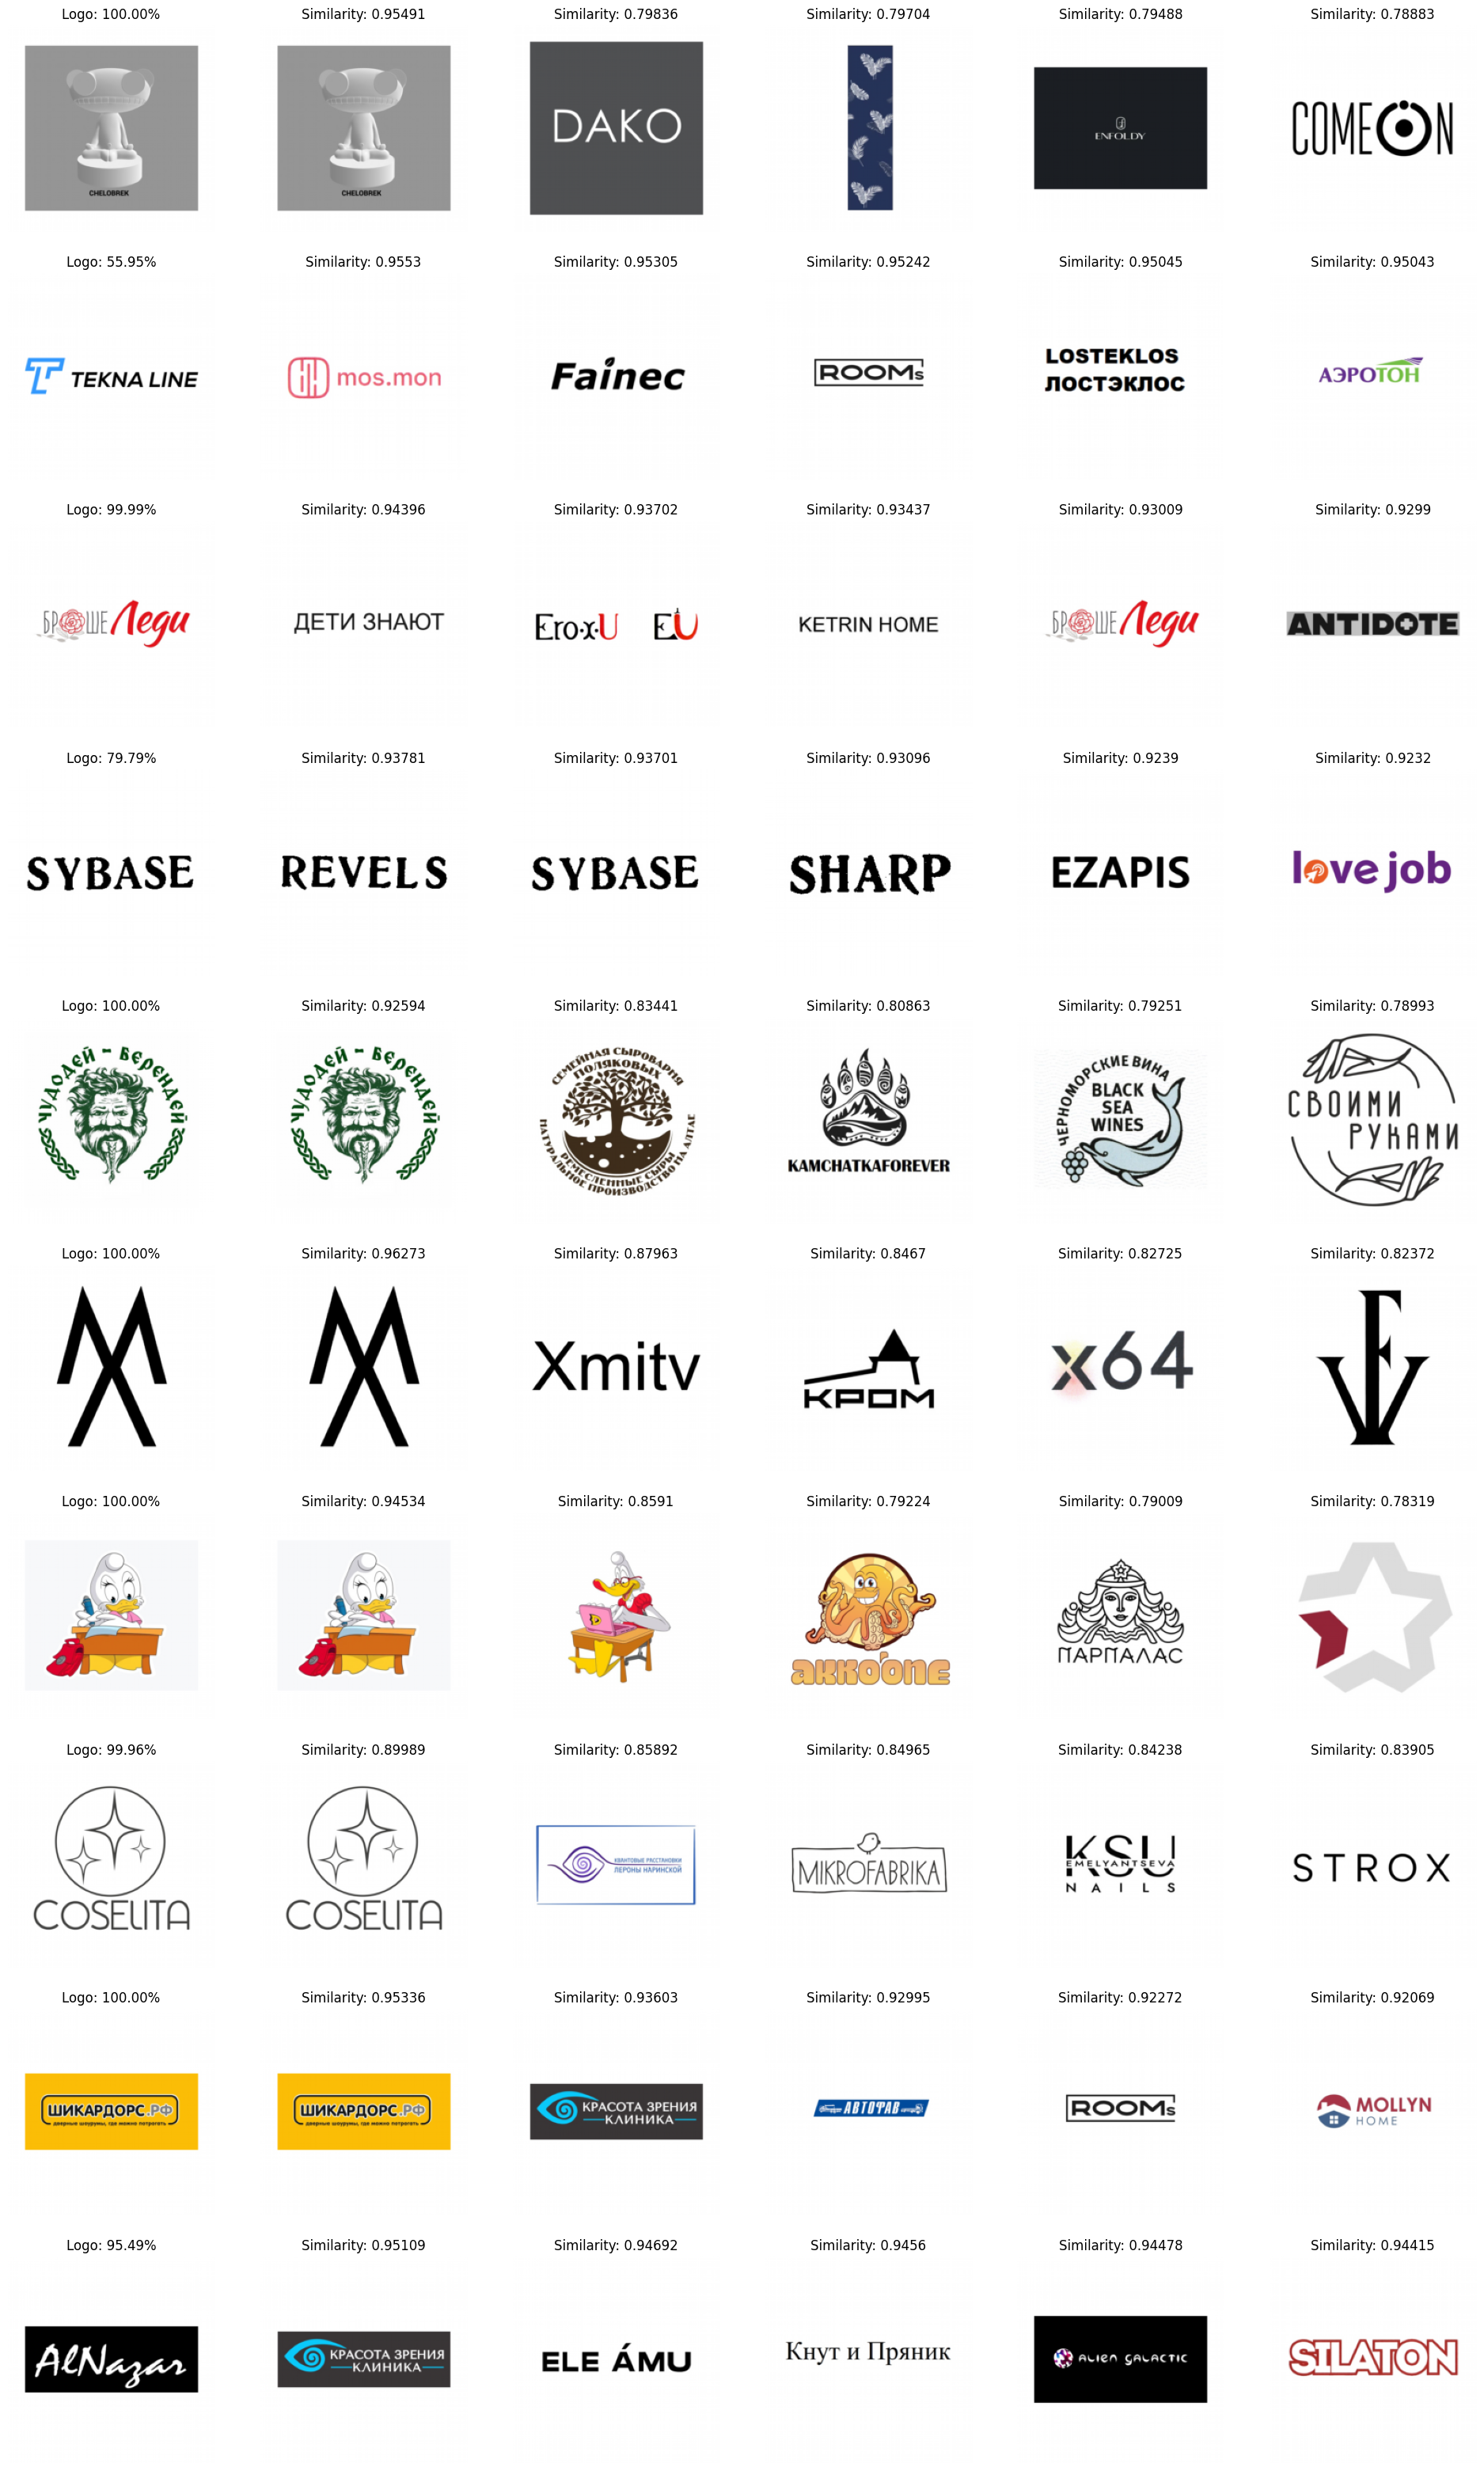

In [20]:
# Use the text-detection model to only check logos
w, h = 6, 10
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

np.random.shuffle(logo_indices)

for i, ax_row in tqdm(enumerate(axs)):
    img_index = logo_indices[i]
    img_path = classification_path[img_index]
    cl = classification[img_index]
    logo_confidence = cl[1].item() * 100

    similarities = compute_similarity(img_path, image_embeddings).cpu().numpy().flatten()
    top_images = np.argsort(similarities)[::-1]

    for i, ax in enumerate(ax_row):
        if i == 0:
            img = load_image(img_path)
            ax.set_title(f'Logo: {logo_confidence:.2f}%', )
        else:
            idx = top_images[i - 1]
            img = load_image(image_embedding_paths[idx])
            similarity = similarities[idx]
            ax.set_title(f'Similarity: {similarity:.5}')
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))

plt.show()

10it [00:00, 20.93it/s]


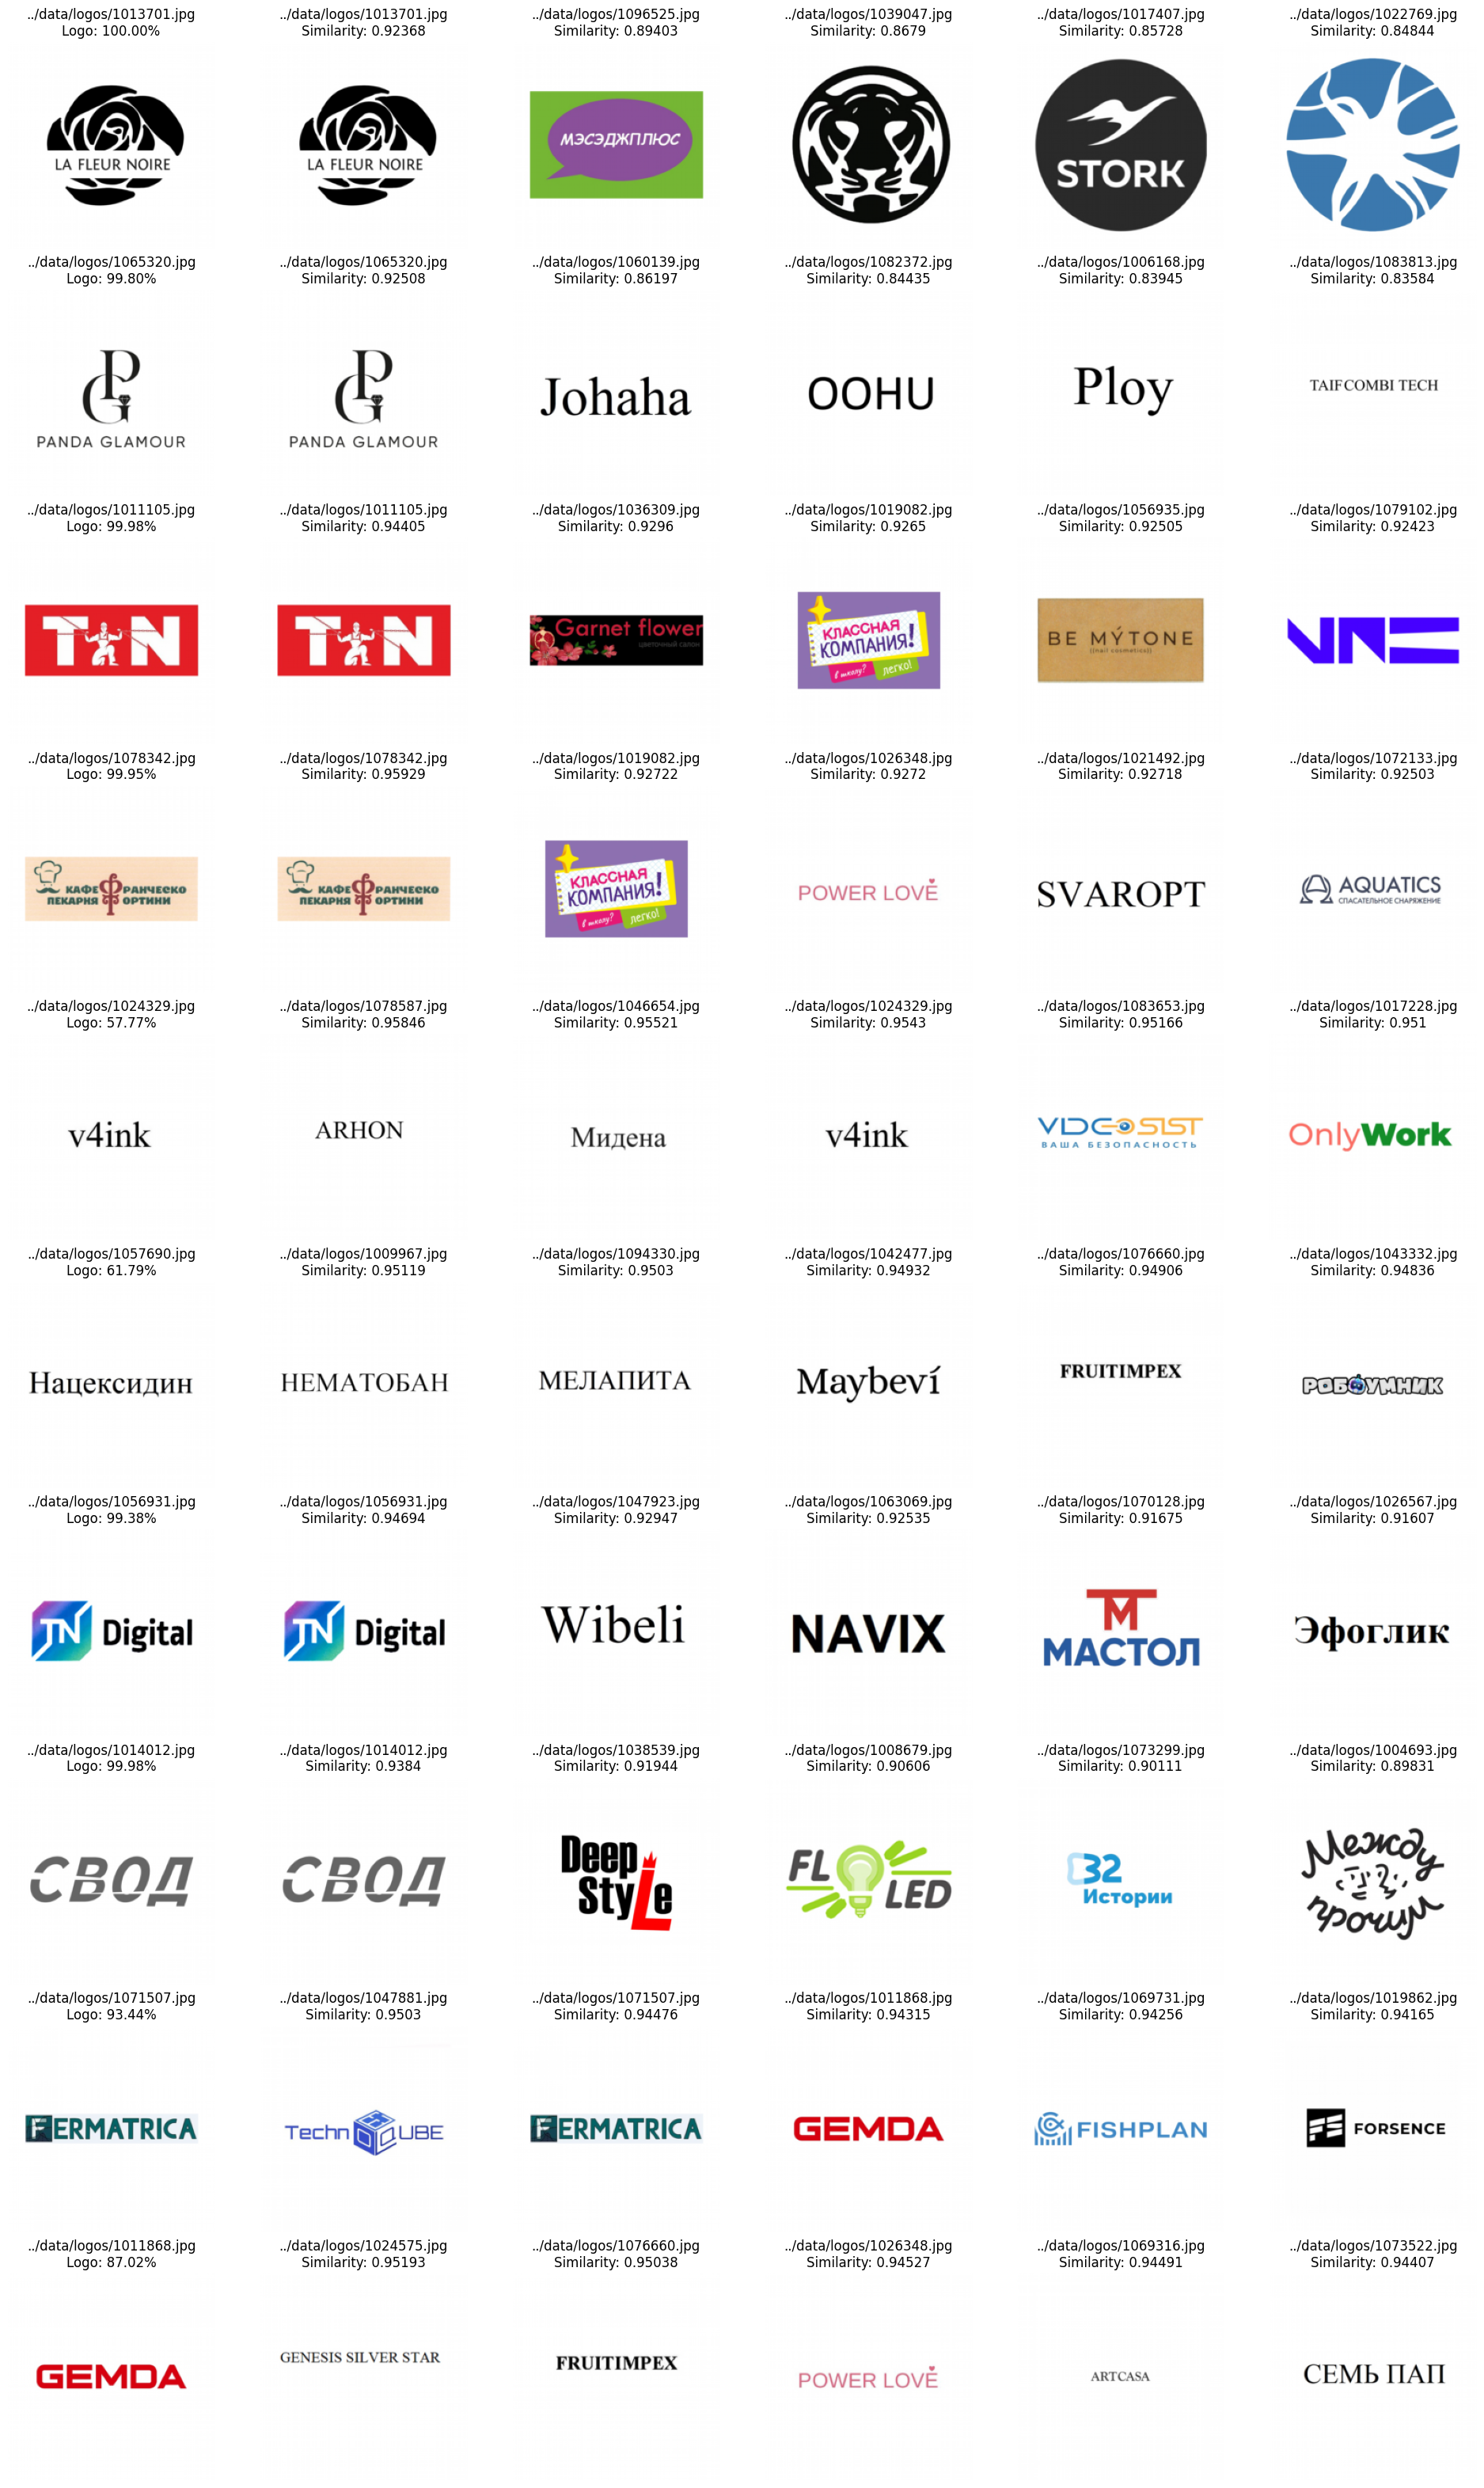

In [44]:
# Use the text-detection model to only check logos
w, h = 6, 10
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

np.random.shuffle(logo_indices)

for i, ax_row in tqdm(enumerate(axs)):
    img_index = logo_indices[i]
    img_path = classification_path[img_index]
    cl = classification[img_index]
    logo_confidence = cl[1].item() * 100

    similarities = compute_similarity(img_path, image_embeddings).cpu().numpy().flatten()
    top_images = np.argsort(similarities)[::-1]

    for i, ax in enumerate(ax_row):
        if i == 0:
            img = load_image(img_path)
            ax.set_title(f'{img_path}\nLogo: {logo_confidence:.2f}%', )
        else:
            idx = top_images[i - 1]
            path = image_embedding_paths[idx]
            img = load_image(path)
            similarity = similarities[idx]
            ax.set_title(f'{path}\nSimilarity: {similarity:.5}')
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))

plt.show()

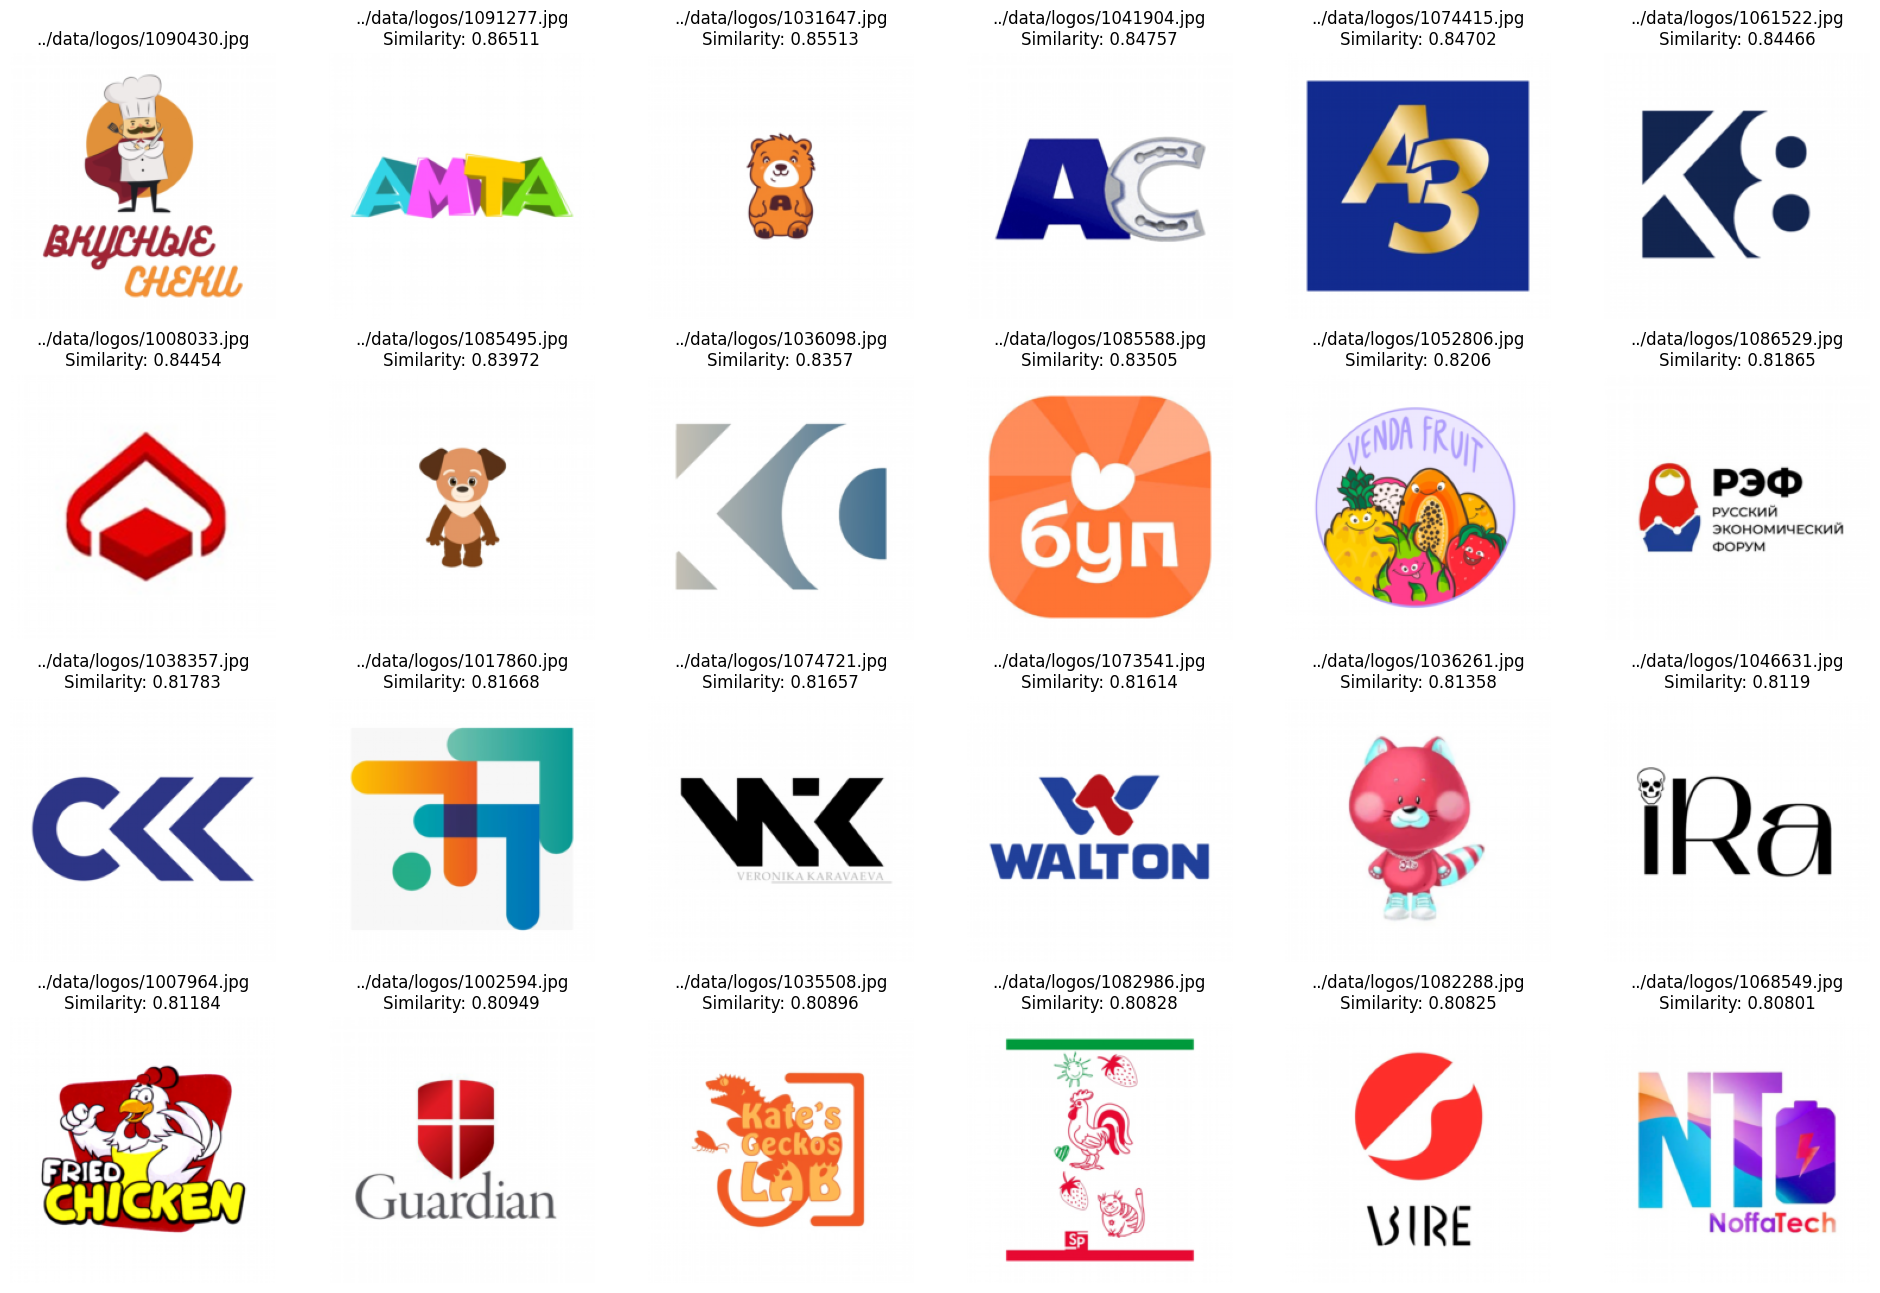

In [34]:
# Check a specific image
w, h = 6, 4
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

#img_path = '../data/logos/1074498.jpg' # bear
#img_path = '../data/logos/1018899.jpg' # dog булкин хвост
#img_path = '../data/logos/1007964.jpg' # fried chicken
#img_path = '../data/logos/1085495.jpg' # bipedal dog
#img_path = '../data/logos/1031647.jpg' # sitting bear?
img_path = '../data/logos/1090430.jpg' # 

similarities = compute_similarity(img_path, image_embeddings).cpu().numpy().flatten()
top_images = np.argsort(similarities)[::-1]

i = 0
for ax_row in axs:
    for ax in ax_row:
        if i == 0:
            img = load_image(img_path)
            ax.set_title(f'{img_path}')
        else:
            idx = top_images[i - 1]
            path = image_embedding_paths[idx]
            img = load_image(path)
            similarity = similarities[idx]
            ax.set_title(f'{path}\nSimilarity: {similarity:.5}')
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))
        i += 1

plt.show()

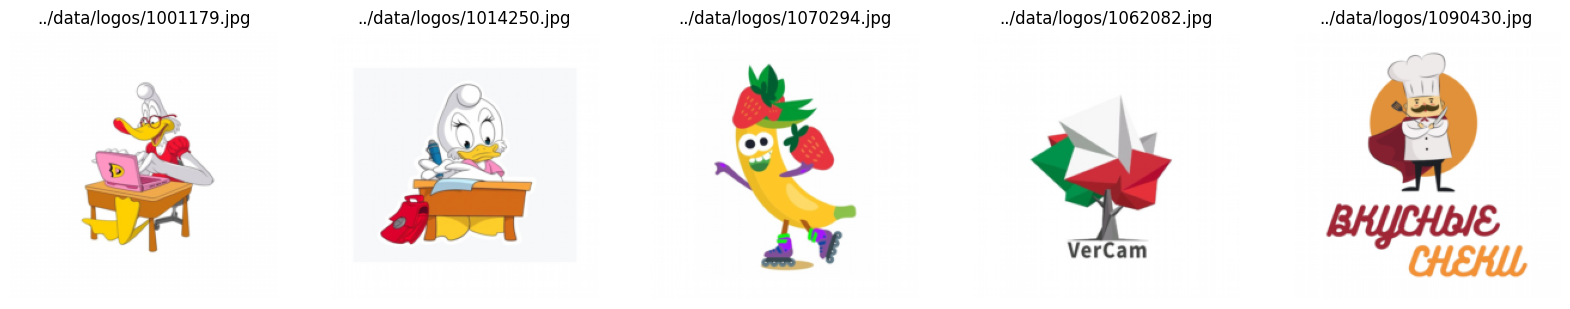

In [27]:
# Check a specific image
w, h = 5, 1
_, ax_row = plt.subplots(h, w, figsize=(w * 4, h * 4))

paths = [
    '../data/logos/1001179.jpg',
    '../data/logos/1014250.jpg',
    '../data/logos/1070294.jpg',
    '../data/logos/1062082.jpg',
    '../data/logos/1090430.jpg',
    '../data/logos/1077599.jpg',
    '../data/logos/1081661.jpg',
    '../data/logos/1068752.jpg',
    '../data/logos/1093562.jpg',
    '../data/logos/1012485.jpg',
]

for i, ax in enumerate(ax_row):
    path = paths[i]
    img = load_image(path)
    similarity = similarities[idx]
    ax.set_title(f'{path}')
    ax.set_axis_off()
    ax.imshow(img.transpose(0,1).transpose(1,2))

plt.show()